# 06. Automated Reject Gate Sweep

`05`까지는 노란 차선 mask를 어떤 방식으로 `.lines.txt` 좌표로 바꿀지 결정했음.

이 노트북의 목적은 이제 **수동 review 목록을 많이 만드는 것**이 아니라, 수천 장 중 사람이 보기 어려운 상황을 전제로 **정말 확실히 불량인 pseudo-label만 자동 reject하는 gate**를 정하는 것임.

중요한 방향 전환:

- 교차로는 학습에서 빼면 안 됨. 오히려 맵 완주에서 어려운 구간이므로 학습에 포함해야 함.
- scene label은 학습 제외 기준이 아니라, 나중에 분석하기 위한 메타데이터임.
- `review_priority`는 사람이 시간이 있을 때 먼저 볼 우선순위일 뿐, 학습 제외 기준이 아님.
- 자동 gate는 `reject / usable`만 결정함.


In [2]:
from pathlib import Path
import json
import itertools
from collections import Counter

import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path('~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization')
EXP_ROOT = PROJECT_ROOT / "10_experiments" / "05_lane_finetune_dataset_pipeline"
REPORTS = EXP_ROOT / "reports"
OUTPUTS = EXP_ROOT / "outputs"
CONFIG_PATH = PROJECT_ROOT / "30_pipelines" / "culane_pseudo_dataset_builder" / "configs" / "project_map_field2_component_poly.json"
DIAG_PATH = REPORTS / "05_full_method_raw_diagnostics.csv"

REPORTS.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = json.load(f)

diag_df = pd.read_csv(DIAG_PATH, encoding="utf-8-sig")
component_df = diag_df[diag_df["method"].eq("component_poly")].copy()

numeric_cols = [
    "num_lanes", "point_total", "median_points", "median_y_span",
    "median_smoothness", "mask_support", "duplicate_component_risk",
    "has_pair", "median_gap", "min_gap", "crossing_risk", "small_gap_risk",
]
for col in numeric_cols:
    if col in component_df.columns:
        component_df[col] = pd.to_numeric(component_df[col], errors="coerce").fillna(0.0)

print(f"diagnostics rows: {len(diag_df)}")
print(f"component_poly rows: {len(component_df)}")
print(f"scenes: {sorted(component_df['scene'].unique())}")


diagnostics rows: 9868
component_poly rows: 2467
scenes: ['failure_cases', 'intersection_approach', 'intersection_left', 'intersection_right', 'left_curve', 'off_center_left', 'off_center_right', 'right_curve', 'straight']


## 1. reject gate와 review priority를 분리함

이전 방식의 문제는 `intersection_*`를 `needs_review`로 보내고, builder가 `auto_accept`만 학습에 넣었다는 점임. 그러면 교차로가 학습에서 빠짐.

이제 기준을 분리함.

- `quality_gate`: pseudo-label 자체가 깨졌는지 판단함. 깨졌으면 `reject`.
- `review_priority`: 교차로/failure/hard case처럼 나중에 우선 확인할 장면을 표시함. 학습 제외 기준은 아님.

즉, 교차로라도 label이 usable하면 학습에 들어감.


In [3]:
quality_gate = config["quality_gate"]
review_priority_policy = config["review_priority_policy"]

print("quality_gate")
print(json.dumps(quality_gate, ensure_ascii=False, indent=2))
print()
print("review_priority_policy")
print(json.dumps(review_priority_policy, ensure_ascii=False, indent=2))


quality_gate
{
  "min_lanes": 1,
  "min_point_total": 12,
  "min_y_span": 80,
  "min_mask_support": 0.2,
  "reject_crossing": false,
  "reject_small_gap": false
}

review_priority_policy
{
  "straight": "normal",
  "left_curve": "normal",
  "right_curve": "normal",
  "off_center_left": "normal",
  "off_center_right": "normal",
  "intersection_approach": "high",
  "intersection_left": "high",
  "intersection_right": "high",
  "failure_cases": "hard_case"
}


## 2. 자동 reject 함수

reject는 보수적으로 잡음. 애매한 것은 최대한 살리고, 진짜 label이 비어 있거나 너무 짧은 경우만 버림.

현재 후보 지표:

- `num_lanes`: 0이면 `.lines.txt`로 학습할 차선이 없음
- `point_total`: 점 개수가 너무 적으면 선이라고 보기 어려움
- `median_y_span`: 화면 세로 방향으로 너무 짧으면 주행 학습에 부적합
- `mask_support`: 생성한 선이 원래 HSV mask 위에 거의 올라가지 않으면 잘못 그은 선일 가능성이 큼
- `crossing_risk`, `small_gap_risk`: 이번에는 reject 기준으로 쓰지 않음. 교차로/복잡 구간에서 오탐처럼 보일 수 있기 때문임.


In [4]:
def reject_reasons(row, gate):
    reasons = []
    if row["num_lanes"] < gate["min_lanes"]:
        reasons.append("no_lane")
    if row["point_total"] < gate["min_point_total"]:
        reasons.append("low_point_total")
    if row["median_y_span"] < gate["min_y_span"]:
        reasons.append("short_y_span")
    if row["mask_support"] < gate["min_mask_support"]:
        reasons.append("low_mask_support")
    if gate.get("reject_crossing", False) and row["crossing_risk"] >= 1:
        reasons.append("crossing_risk")
    if gate.get("reject_small_gap", False) and row["small_gap_risk"] >= 1:
        reasons.append("small_gap_risk")
    return reasons

def apply_gate(df, gate):
    out = df.copy()
    out["reject_reasons"] = out.apply(lambda row: reject_reasons(row, gate), axis=1)
    out["quality_status"] = np.where(out["reject_reasons"].map(len).gt(0), "reject", "usable")
    out["review_priority"] = out["scene"].map(review_priority_policy).fillna("normal")
    return out

gated_df = apply_gate(component_df, quality_gate)
display(gated_df["quality_status"].value_counts().to_frame("count"))
display(pd.crosstab(gated_df["scene"], gated_df["quality_status"]))


,count
quality_status,
usable,2396
reject,71


quality_status,reject,usable
scene,,
failure_cases,71,417
intersection_approach,0,93
intersection_left,0,285
intersection_right,0,287
left_curve,0,227
off_center_left,0,344
off_center_right,0,455
right_curve,0,231
straight,0,57


## 3. threshold 후보 sweep

여기서 목표는 “많이 걸러내기”가 아님. 수동 검수가 어렵기 때문에, 자동으로 버려도 후회가 적은 확실한 불량 조건만 찾는 것임.

따라서 reject 수가 갑자기 교차로/곡선으로 번지는 threshold는 위험한 기준으로 봄.


In [5]:
sweep_rows = []
min_point_options = [8, 12, 20, 28, 36]
min_span_options = [40, 60, 80, 100, 120]
min_support_options = [0.0, 0.1, 0.2, 0.3, 0.35, 0.5]

for min_point_total, min_y_span, min_mask_support in itertools.product(
    min_point_options,
    min_span_options,
    min_support_options,
):
    gate = {
        "min_lanes": 1,
        "min_point_total": min_point_total,
        "min_y_span": min_y_span,
        "min_mask_support": min_mask_support,
        "reject_crossing": False,
        "reject_small_gap": False,
    }
    out = apply_gate(component_df, gate)
    reject_df = out[out["quality_status"].eq("reject")]
    scene_counts = reject_df["scene"].value_counts().to_dict()
    sweep_rows.append({
        **gate,
        "usable": int(out["quality_status"].eq("usable").sum()),
        "reject": int(out["quality_status"].eq("reject").sum()),
        "reject_failure_cases": int(scene_counts.get("failure_cases", 0)),
        "reject_intersections": int(sum(scene_counts.get(s, 0) for s in ["intersection_approach", "intersection_left", "intersection_right"])),
        "reject_core_driving": int(sum(scene_counts.get(s, 0) for s in ["straight", "left_curve", "right_curve", "off_center_left", "off_center_right"])),
    })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df["is_selected_gate"] = (
    sweep_df["min_lanes"].eq(quality_gate["min_lanes"])
    & sweep_df["min_point_total"].eq(quality_gate["min_point_total"])
    & sweep_df["min_y_span"].eq(quality_gate["min_y_span"])
    & sweep_df["min_mask_support"].eq(quality_gate["min_mask_support"])
)

sweep_path = REPORTS / "06_automated_reject_gate_sweep.csv"
sweep_df.to_csv(sweep_path, index=False, encoding="utf-8-sig")
print(sweep_path)

focus = sweep_df[
    sweep_df["min_point_total"].isin([8, 12, 20, 28])
    & sweep_df["min_y_span"].isin([60, 80, 100, 120])
    & sweep_df["min_mask_support"].isin([0.0, 0.2, 0.35, 0.5])
].copy()
display(focus.sort_values(["reject", "reject_intersections", "reject_core_driving"]).head(40))


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline\reports\06_automated_reject_gate_sweep.csv


,min_lanes,min_point_total,min_y_span,min_mask_support,reject_crossing,reject_small_gap,usable,reject,reject_failure_cases,reject_intersections,reject_core_driving,is_selected_gate
6,1,8,60,0.00,False,False,2396,71,71,0,0,False
8,1,8,60,0.20,False,False,2396,71,71,0,0,False
12,1,8,80,0.00,False,False,2396,71,71,0,0,False
14,1,8,80,0.20,False,False,2396,71,71,0,0,False
18,1,8,100,0.00,False,False,2396,71,71,0,0,False
20,1,8,100,0.20,False,False,2396,71,71,0,0,False
36,1,12,60,0.00,False,False,2396,71,71,0,0,False
38,1,12,60,0.20,False,False,2396,71,71,0,0,False
42,1,12,80,0.00,False,False,2396,71,71,0,0,False
44,1,12,80,0.20,False,False,2396,71,71,0,0,True


## 4. 선택 gate의 reject 샘플 확인

선택 gate가 버리는 이미지가 무엇인지 확인함. 여기서 reject가 대부분 no-lane/empty에 가까우면 자동화 기준으로 안전함.


In [6]:
selected = apply_gate(component_df, quality_gate)
reject_df = selected[selected["quality_status"].eq("reject")].copy()
usable_df = selected[selected["quality_status"].eq("usable")].copy()

print("selected gate")
print(json.dumps(quality_gate, ensure_ascii=False, indent=2))
print()
print("quality status counts")
print(selected["quality_status"].value_counts().to_string())
print()
print("reject scenes")
print(reject_df["scene"].value_counts().to_string())
print()
print("usable review priority")
print(usable_df["review_priority"].value_counts().to_string())

reject_df["reject_reason_text"] = reject_df["reject_reasons"].map(lambda xs: ";".join(xs))
display(reject_df[["scene", "file", "num_lanes", "point_total", "median_y_span", "mask_support", "reject_reason_text"]].head(30))


selected gate
{
  "min_lanes": 1,
  "min_point_total": 12,
  "min_y_span": 80,
  "min_mask_support": 0.2,
  "reject_crossing": false,
  "reject_small_gap": false
}

quality status counts
quality_status
usable    2396
reject      71

reject scenes
scene
failure_cases    71

usable review priority
review_priority
normal       1314
high          665
hard_case     417


,scene,file,num_lanes,point_total,median_y_span,mask_support,reject_reason_text
7999,failure_cases,20260501_114529_01_lane_drive_capture_failure_...,0,0,0.0,0.0,no_lane;low_point_total;short_y_span;low_mask_...
8003,failure_cases,20260501_114529_01_lane_drive_capture_failure_...,0,0,0.0,0.0,no_lane;low_point_total;short_y_span;low_mask_...
8007,failure_cases,20260501_114529_01_lane_drive_capture_failure_...,0,0,0.0,0.0,no_lane;low_point_total;short_y_span;low_mask_...
8011,failure_cases,20260501_114530_01_lane_drive_capture_failure_...,0,0,0.0,0.0,no_lane;low_point_total;short_y_span;low_mask_...
8015,failure_cases,20260501_114530_01_lane_drive_capture_failure_...,0,0,0.0,0.0,no_lane;low_point_total;short_y_span;low_mask_...
8019,failure_cases,20260501_114530_01_lane_drive_capture_failure_...,0,0,0.0,0.0,no_lane;low_point_total;short_y_span;low_mask_...
8023,failure_cases,20260501_114530_01_lane_drive_capture_failure_...,0,0,0.0,0.0,no_lane;low_point_total;short_y_span;low_mask_...
8027,failure_cases,20260501_114531_01_lane_drive_capture_failure_...,0,0,0.0,0.0,no_lane;low_point_total;short_y_span;low_mask_...
8031,failure_cases,20260501_114531_01_lane_drive_capture_failure_...,0,0,0.0,0.0,no_lane;low_point_total;short_y_span;low_mask_...
8035,failure_cases,20260501_114531_01_lane_drive_capture_failure_...,0,0,0.0,0.0,no_lane;low_point_total;short_y_span;low_mask_...


## 5. reject 예시를 이미지로 확인함

자동 gate가 걸러낸 샘플을 표만으로 보면 직관이 부족함. 여기서는 reject된 이미지 몇 장을 `raw / HSV mask / pseudo-lane overlay` 형태로 확인함. 목적은 reject가 scene을 임의로 배제한 것이 아니라, 실제로 노란 차선 pseudo-label이 거의 생성되지 않은 확실한 불량을 걸러내는지 확인하는 것임.


showing 8 reject examples / total reject 71


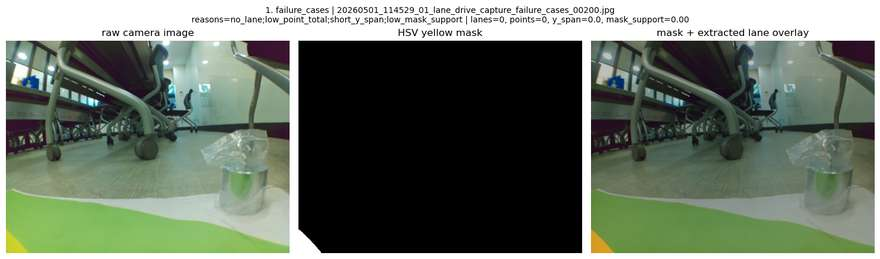

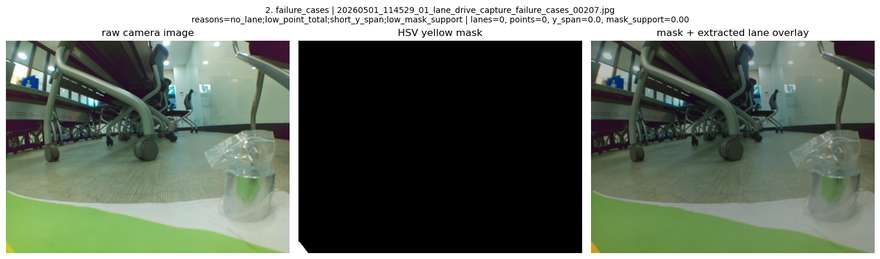

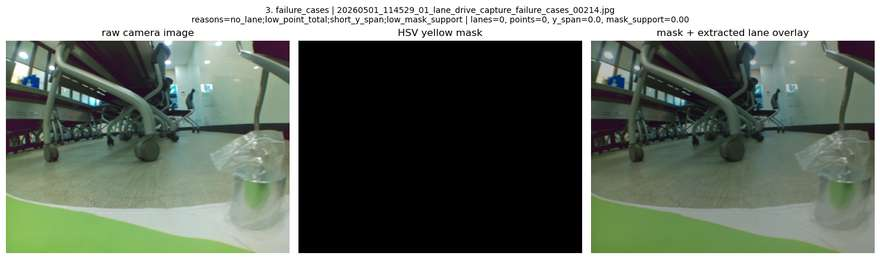

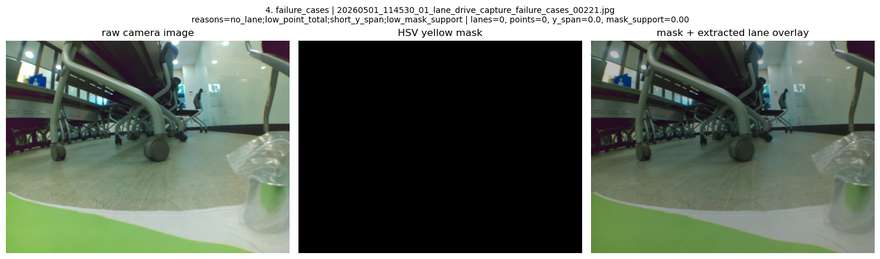

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PIPELINE_SRC = PROJECT_ROOT / "30_pipelines" / "culane_pseudo_dataset_builder" / "src"
if str(PIPELINE_SRC) not in sys.path:
    sys.path.insert(0, str(PIPELINE_SRC))

import culane_builder_common as cb

geom = cb.CameraGeometry.from_config(config["camera"])
input_cfg = config["input"]
manifest_path = PROJECT_ROOT / input_cfg["manifest_csv"]
manifest_df = pd.read_csv(manifest_path, encoding="utf-8-sig")
manifest_df["file_name"] = manifest_df["raw_path"].map(lambda p: Path(str(p)).name)
manifest_by_file = manifest_df.drop_duplicates("file_name").set_index("file_name")

hsv_cfg = config["hsv"]
method_cfg = config["lane_extraction"]
method = method_cfg["method"]
method_params = {k: v for k, v in method_cfg.items() if k != "method"}
crop_before_hsv = bool(config.get("preprocess", {}).get("crop_before_hsv", True))

# 너무 많은 이미지를 한 번에 띄우면 노트북이 무거워지므로 기본 8장만 확인함.
N_REJECT_EXAMPLES = 8
reject_examples = reject_df.sort_values(
    ["scene", "num_lanes", "point_total", "median_y_span", "mask_support"],
    ascending=[True, True, True, True, True],
).head(N_REJECT_EXAMPLES).copy()

print(f"showing {len(reject_examples)} reject examples / total reject {len(reject_df)}")

for i, (_, row) in enumerate(reject_examples.iterrows(), start=1):
    file_name = row["file"]
    if file_name not in manifest_by_file.index:
        print(f"[{i}] manifest에서 파일을 찾지 못함: {file_name}")
        continue

    raw_path = cb.resolve_input_path(str(manifest_by_file.loc[file_name, "raw_path"]), input_cfg)
    if raw_path is None or not cb.path_exists(raw_path):
        print(f"[{i}] raw image를 찾지 못함: {raw_path}")
        continue

    rgb = cb.load_rgb(raw_path)
    mask = cb.yellow_mask_raw(rgb, hsv_cfg, geom, crop_before_hsv=crop_before_hsv)
    lanes, quality = cb.extract_lanes_by_method(mask, geom=geom, method=method, **method_params)
    overlay = cb.overlay_lanes(rgb, lanes, mask=mask)

    reason_text = ";".join(row["reject_reasons"])
    title = (
        f"{i}. {row['scene']} | {file_name}\n"
        f"reasons={reason_text} | lanes={int(row['num_lanes'])}, "
        f"points={int(row['point_total'])}, y_span={row['median_y_span']:.1f}, "
        f"mask_support={row['mask_support']:.2f}"
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].imshow(rgb)
    axes[0].set_title("raw camera image")
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("HSV yellow mask")
    axes[2].imshow(overlay)
    axes[2].set_title("mask + extracted lane overlay")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()


## 6. soft warning은 기록만 함

`crossing_risk`, `small_gap_risk`, `low mask support warning` 같은 값은 유용한 힌트지만, 이번 단계에서는 reject 기준으로 쓰지 않음.

이유는 교차로/복잡 구간에서 이런 값이 나올 수 있고, 그런 장면을 학습에서 빼버리면 프로젝트 목적과 어긋나기 때문임.


In [8]:
warning_df = usable_df.copy()
warning_df["low_mask_support_warn"] = warning_df["mask_support"].lt(0.5)
warning_df["crossing_warn"] = warning_df["crossing_risk"].ge(1)
warning_df["small_gap_warn"] = warning_df["small_gap_risk"].ge(1)
warning_df["any_soft_warning"] = warning_df[["low_mask_support_warn", "crossing_warn", "small_gap_warn"]].any(axis=1)

warning_summary = {
    "usable_total": int(len(warning_df)),
    "low_mask_support_warn": int(warning_df["low_mask_support_warn"].sum()),
    "crossing_warn": int(warning_df["crossing_warn"].sum()),
    "small_gap_warn": int(warning_df["small_gap_warn"].sum()),
    "any_soft_warning": int(warning_df["any_soft_warning"].sum()),
}
print(json.dumps(warning_summary, ensure_ascii=False, indent=2))
display(pd.crosstab(warning_df["scene"], warning_df["any_soft_warning"]))


{
  "usable_total": 2396,
  "low_mask_support_warn": 48,
  "crossing_warn": 112,
  "small_gap_warn": 112,
  "any_soft_warning": 160
}


any_soft_warning,False,True
scene,,
failure_cases,350,67
intersection_approach,92,1
intersection_left,233,52
intersection_right,265,22
left_curve,227,0
off_center_left,341,3
off_center_right,440,15
right_curve,231,0
straight,57,0


## 7. 결정 report 저장

이 report는 재사용 빌더 config와 같은 의미를 갖도록 저장함.


In [9]:
selected_counts = selected["quality_status"].value_counts().to_dict()
reject_scene_counts = reject_df["scene"].value_counts().to_dict()
usable_priority_counts = usable_df["review_priority"].value_counts().to_dict()

decision_report = {
    "source_diagnostics": str(DIAG_PATH),
    "method": "component_poly",
    "selected_quality_gate": quality_gate,
    "quality_status_counts": {str(k): int(v) for k, v in selected_counts.items()},
    "reject_scene_counts": {str(k): int(v) for k, v in reject_scene_counts.items()},
    "usable_review_priority_counts": {str(k): int(v) for k, v in usable_priority_counts.items()},
    "sweep_csv": str(REPORTS / "06_automated_reject_gate_sweep.csv"),
    "soft_warning_summary": warning_summary,
    "interpretation": [
        "quality gate는 scene을 학습에서 제외하지 않고, pseudo-label이 확실히 깨진 경우만 reject함.",
        "교차로와 failure_cases 중 usable한 샘플도 학습 후보로 유지함.",
        "review_priority는 수동 검수 우선순위 메타데이터일 뿐, train include 여부를 결정하지 않음.",
        "이번 선택 gate는 no-lane/empty 계열 71장을 reject하고, 나머지 2396장을 usable로 둠.",
    ],
}
report_path = REPORTS / "06_automated_reject_gate_decision_report.json"
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(decision_report, f, ensure_ascii=False, indent=2)

print(report_path)
print(json.dumps(decision_report, ensure_ascii=False, indent=2))


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline\reports\06_automated_reject_gate_decision_report.json
{
  "source_diagnostics": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\05_lane_finetune_dataset_pipeline\\reports\\05_full_method_raw_diagnostics.csv",
  "method": "component_poly",
  "selected_quality_gate": {
    "min_lanes": 1,
    "min_point_total": 12,
    "min_y_span": 80,
    "min_mask_support": 0.2,
    "reject_crossing": false,
    "reject_small_gap": false
  },
  "quality_status_counts": {
    "usable": 2396,
    "reject": 71
  },
  "reject_scene_counts": {
    "failure_cases": 71
  },
  "usable_review_priority_counts": {
    "normal": 1314,
    "high": 665,
    "hard_case": 417
  },
  "sweep_csv": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\05_lane_finetune_dataset_pipeline\\reports\\06_automated_reject_gate_sweep.csv",
  

## 06 결과 메모

이 노트북은 기존의 scene 기반 `auto_accept / needs_review / holdout` 정책을 버리고, **정말 확실한 불량 pseudo-label만 자동 reject하는 quality gate**로 재정의했음.

확정 gate는 아래와 같음.

```json
{
  "min_lanes": 1,
  "min_point_total": 12,
  "min_y_span": 80,
  "min_mask_support": 0.2,
  "reject_crossing": false,
  "reject_small_gap": false
}
```

전체 `component_poly` 결과 2467장에 적용한 결과는 다음과 같음.

- `usable`: `2396장`
- `reject`: `71장`
- reject scene: `failure_cases 71장`

usable 데이터의 review priority는 다음처럼 기록만 함. 학습 제외 기준이 아님.

- `normal`: `1314장`
- `high`: `665장`
- `hard_case`: `417장`

soft warning은 `low_mask_support`, `crossing_risk`, `small_gap_risk`를 표시하지만 reject하지 않음. 현재 usable 중 soft warning은 `160장`임. 교차로와 복잡 구간을 학습에서 빼지 않기 위해, warning은 분석용 메타데이터로만 남김.

따라서 다음 builder 단계에서는 `usable` 2396장을 train/val 후보로 사용하고, `reject` 71장만 제외하는 것이 맞음.
